# 02 — Exploratory Data Analysis & Statistical Tests

## Overview
This notebook documents the EDA and statistical validation pipeline. All analyses are performed on the cleaned dataset from Notebook 01.

## Sections
1. **Genre Analysis** — Distribution, weighted ratings, performance comparison
2. **Price Analysis** — Price vs rating relationship, distribution, price groups
3. **Temporal Trends** — Release patterns over time, rating evolution
4. **Popularity vs Quality** — Owners vs Wilson Score correlation
5. **Developer Rankings** — Top developers by weighted rating
6. **Statistical Tests** — T-test, ANOVA, Pearson correlation, normality checks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats
import os

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
PROCESSED_PATH = os.path.join(BASE_DIR, 'data', 'processed', 'steam_games_with_genres.csv')

df = pd.read_csv(PROCESSED_PATH)
# Parse genres
import ast
df['genres'] = df['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x)
# Compute total_ratings on the fly (redundant column was removed)
df['total_ratings'] = df['positive_ratings'] + df['negative_ratings']

print(f'Dataset: {len(df):,} games, {len(df.columns)} columns')
print(f'Year range: {df["year"].min()}-{df["year"].max()}')
print(f'Price range: ${df["price"].min():.2f} - ${df["price"].max():.2f}')
df.head(3)

Dataset: 3,868 games, 43 columns
Year range: 2022-2026
Price range: $0.00 - $99.99


,appid,name,release_date,year,developer,publisher,price,is_free,discount,price_group,...,genre_Photo Editing,genre_RPG,genre_Racing,genre_Simulation,genre_Sports,genre_Strategy,genre_Utilities,genre_Video Production,genre_Web Publishing,total_ratings
0,1623730,Palworld,2024-01-18,2024,Pocketpair,Pocketpair,29.99,0,0,$10-30,...,0,1,0,0,0,0,0,0,0,380709
1,1938090,Call of Duty: Modern Warfare II,2022-10-27,2022,Treyarch,Activision,69.99,0,45,>$30,...,0,0,0,0,0,0,0,0,0,714114
2,2358720,Black Myth: Wukong,2024-08-19,2024,Game Science,Game Science,59.99,0,0,>$30,...,0,1,0,0,0,0,0,0,0,1150098


## 1. Genre Analysis

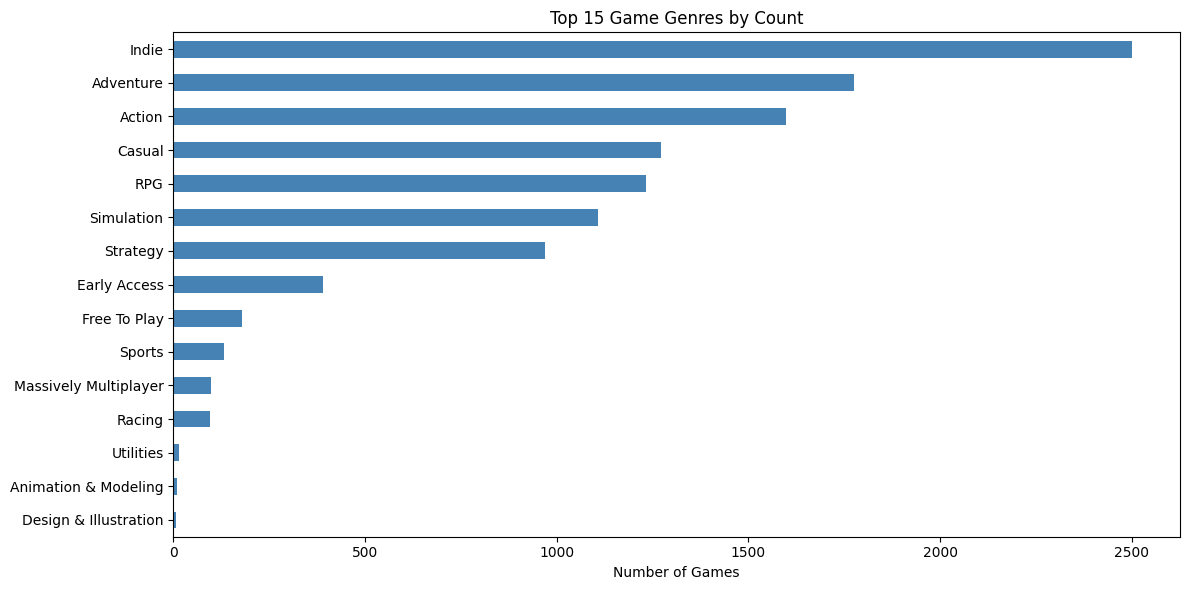

Genre distribution:
Indie                    2501
Adventure                1776
Action                   1598
Casual                   1272
RPG                      1232
Simulation               1107
Strategy                  970
Early Access              391
Free To Play              178
Sports                    133
Massively Multiplayer      97
Racing                     95
Utilities                  15
Animation & Modeling       10
Design & Illustration       7
Game Development            4
Video Production            2
Accounting                  1
Audio Production            1
Education                   1
Photo Editing               1
Web Publishing              1
dtype: int64


In [2]:
# Genre distribution
genre_cols = [c for c in df.columns if c.startswith('genre_')]
genre_counts = df[genre_cols].sum().sort_values(ascending=False)
genre_counts.index = [i.replace('genre_', '') for i in genre_counts.index]

fig, ax = plt.subplots(figsize=(12, 6))
genre_counts.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of Games')
ax.set_title('Top 15 Game Genres by Count')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Genre distribution:')
print(genre_counts)

                Genre  Games  Weighted Rating  Weighted Wilson  Avg Price
               Casual   1272         0.903496         0.895048  10.564245
                Indie   2501         0.894184         0.886518  11.705242
            Adventure   1776         0.876926         0.871440  16.137050
         Early Access    391         0.859232         0.854583  14.001995
                  RPG   1232         0.857913         0.852730  17.240244
               Action   1598         0.854374         0.849714  17.223098
             Strategy    970         0.851460         0.841816  15.572629
           Simulation   1107         0.832337         0.824286  15.265366
         Free To Play    178         0.800344         0.792331   1.796404
Massively Multiplayer     97         0.773285         0.767334  10.429794
               Racing     95         0.773771         0.764018  22.685684
               Sports    133         0.645240         0.638711  20.623158


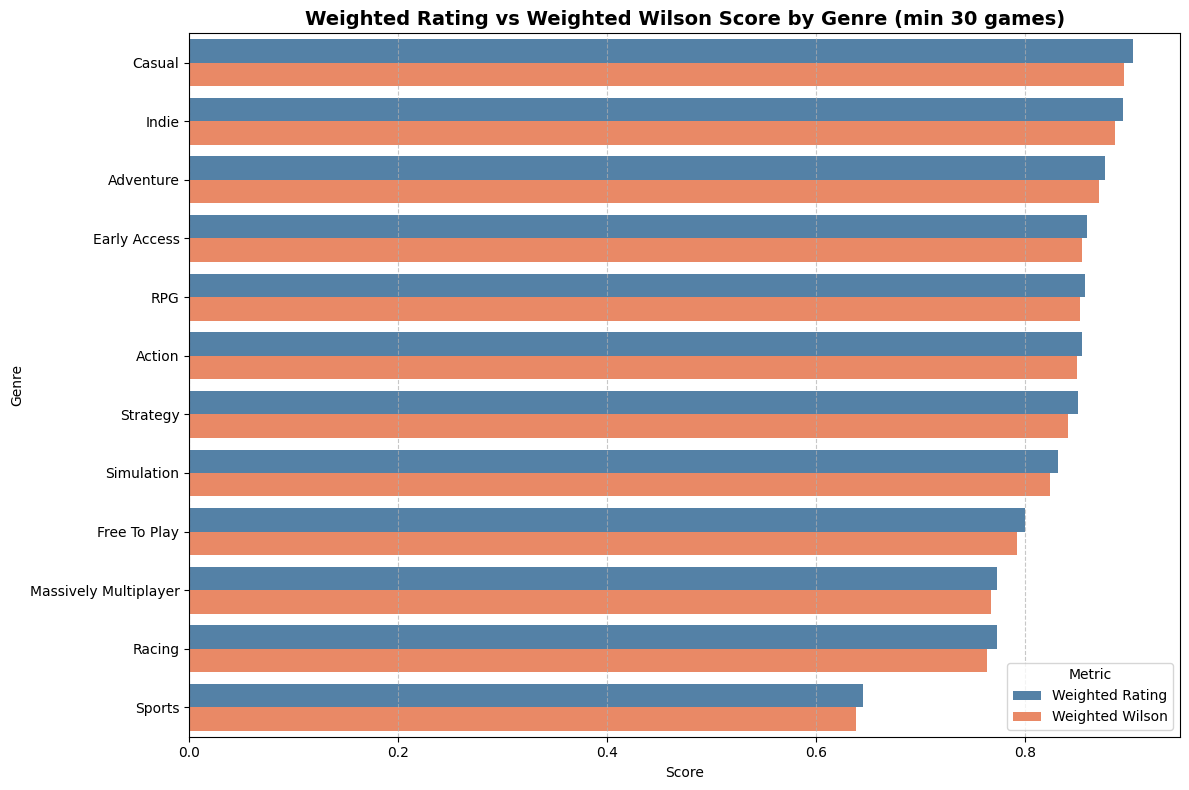

In [3]:
# Weighted rating by genre (weighted by total_ratings)
genre_perf = []
for col in genre_cols:
    name = col.replace('genre_', '')
    mask = df[col] == 1
    if mask.sum() >= 30:
        tr = df.loc[mask, 'total_ratings']
        wr = (df.loc[mask, 'rating_ratio'] * tr).sum() / tr.sum()
        ws = (df.loc[mask, 'wilson_score'] * tr).sum() / tr.sum()
        genre_perf.append({
            'Genre': name, 'Games': int(mask.sum()),
            'Weighted Rating': wr, 'Weighted Wilson': ws,
            'Avg Price': df.loc[mask, 'price'].mean(),
        })

perf_df = pd.DataFrame(genre_perf).sort_values('Weighted Wilson', ascending=False)
print(perf_df.to_string(index=False))

# Visualize Weighted Rating vs Weighted Wilson Score by Genre
perf_melted = perf_df.melt(id_vars='Genre', value_vars=['Weighted Rating', 'Weighted Wilson'],
                           var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    x='Score',
    y='Genre',
    hue='Metric',
    data=perf_melted,
    palette=['steelblue', 'coral'],
    ax=ax
)
ax.set_title('Weighted Rating vs Weighted Wilson Score by Genre (min 30 games)', fontsize=14, fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Genre')
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 2. Price Analysis

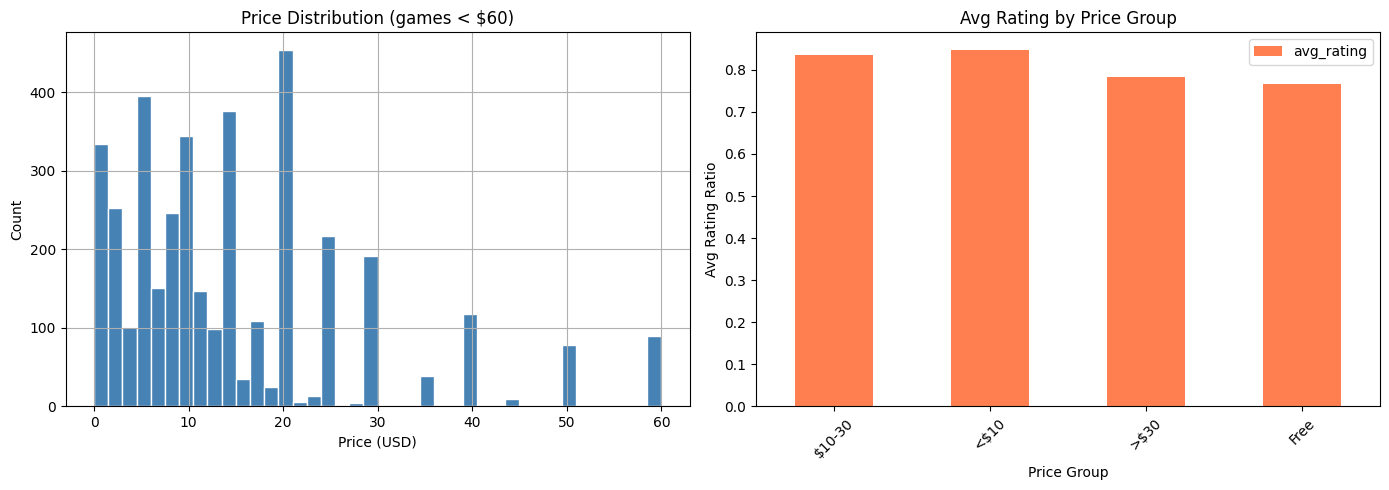

Price group summary:
             games  avg_rating  avg_wilson  avg_price
price_group                                          
$10-30        1678       0.835       0.804     19.292
<$10          1569       0.847       0.809      6.236
>$30           365       0.783       0.764     49.209
Free           256       0.767       0.726      0.000


In [4]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
df[df['price'] < 60]['price'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price Distribution (games < $60)')

# Price group breakdown
pg = df.groupby('price_group').agg(
    games=('name', 'count'),
    avg_rating=('rating_ratio', 'mean'),
    avg_wilson=('wilson_score', 'mean'),
    avg_price=('price', 'mean'),
).round(3)
pg.plot(kind='bar', y='avg_rating', ax=axes[1], color='coral')
axes[1].set_xlabel('Price Group')
axes[1].set_ylabel('Avg Rating Ratio')
axes[1].set_title('Avg Rating by Price Group')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Price group summary:')
print(pg)

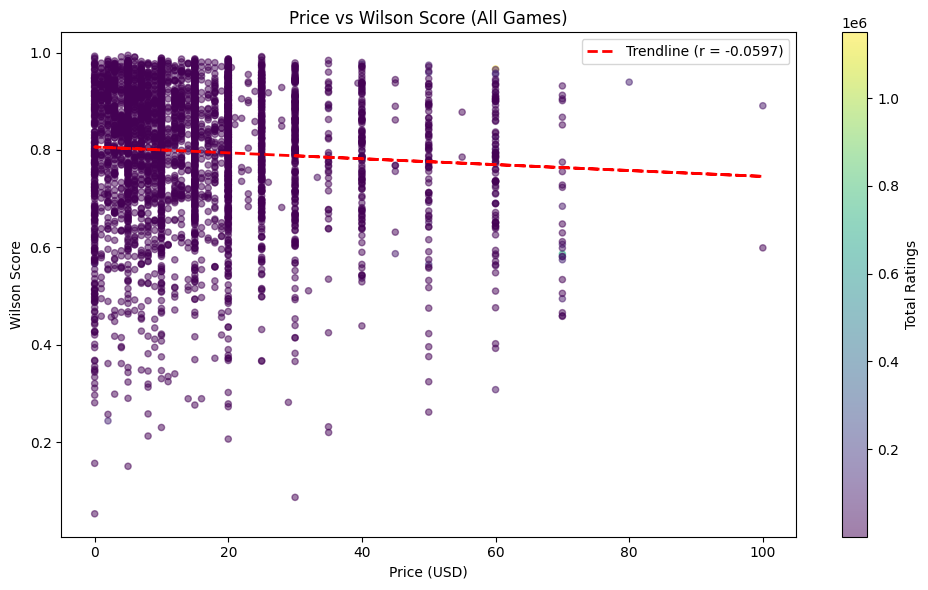

Pearson r = -0.0597, p = 2.02e-04
Price explains 0.4% of Wilson Score variance


In [5]:
# Price vs Wilson Score scatter (all games)
# Pearson correlation
r, p = scipy_stats.pearsonr(df['price'], df['wilson_score'])

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['price'], df['wilson_score'],
    c=df['total_ratings'], cmap='viridis', alpha=0.5, s=20)

# Fit linear regression for trendline
m, b = np.polyfit(df['price'], df['wilson_score'], 1)
ax.plot(df['price'], m * df['price'] + b, color='red', linestyle='--', linewidth=2, label=f'Trendline (r = {r:.4f})')

ax.set_xlabel('Price (USD)')
ax.set_ylabel('Wilson Score')
ax.set_title('Price vs Wilson Score (All Games)')
plt.colorbar(scatter, ax=ax, label='Total Ratings')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Pearson r = {r:.4f}, p = {p:.2e}')
print(f'Price explains {r**2 * 100:.1f}% of Wilson Score variance')


## 3. Popularity vs Quality

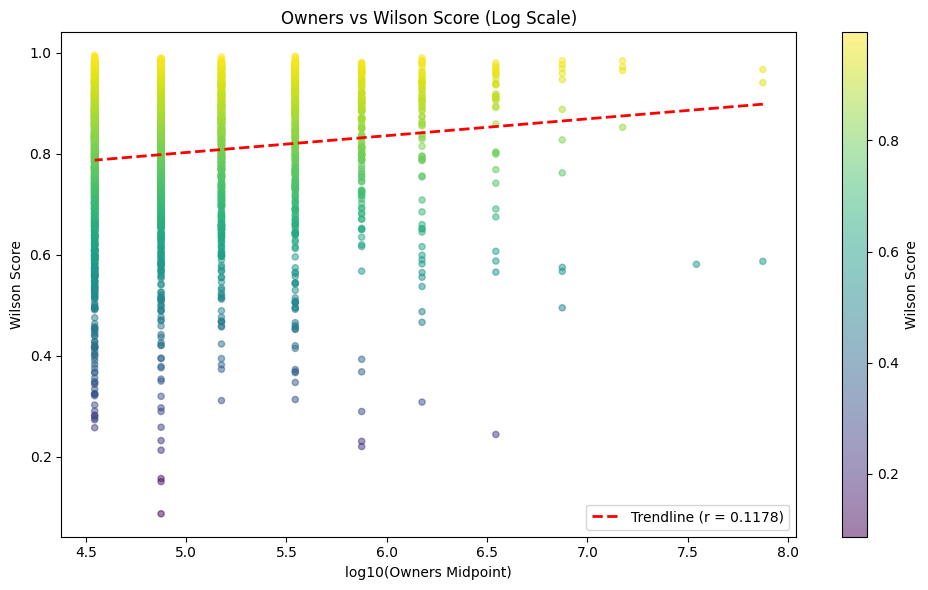

Pearson correlation (log10(owners) vs wilson_score): r = 0.1178, p = 7.75e-11
Spearman rank correlation (owners vs wilson_score): rho = 0.1518, p = 4.23e-17

=== One-way ANOVA: Popularity Tiers ===
F-statistic = 15.089
p-value = 3.04e-12


C:\Users\Tuyen\AppData\Local\Temp\ipykernel_24800\547393684.py:77: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


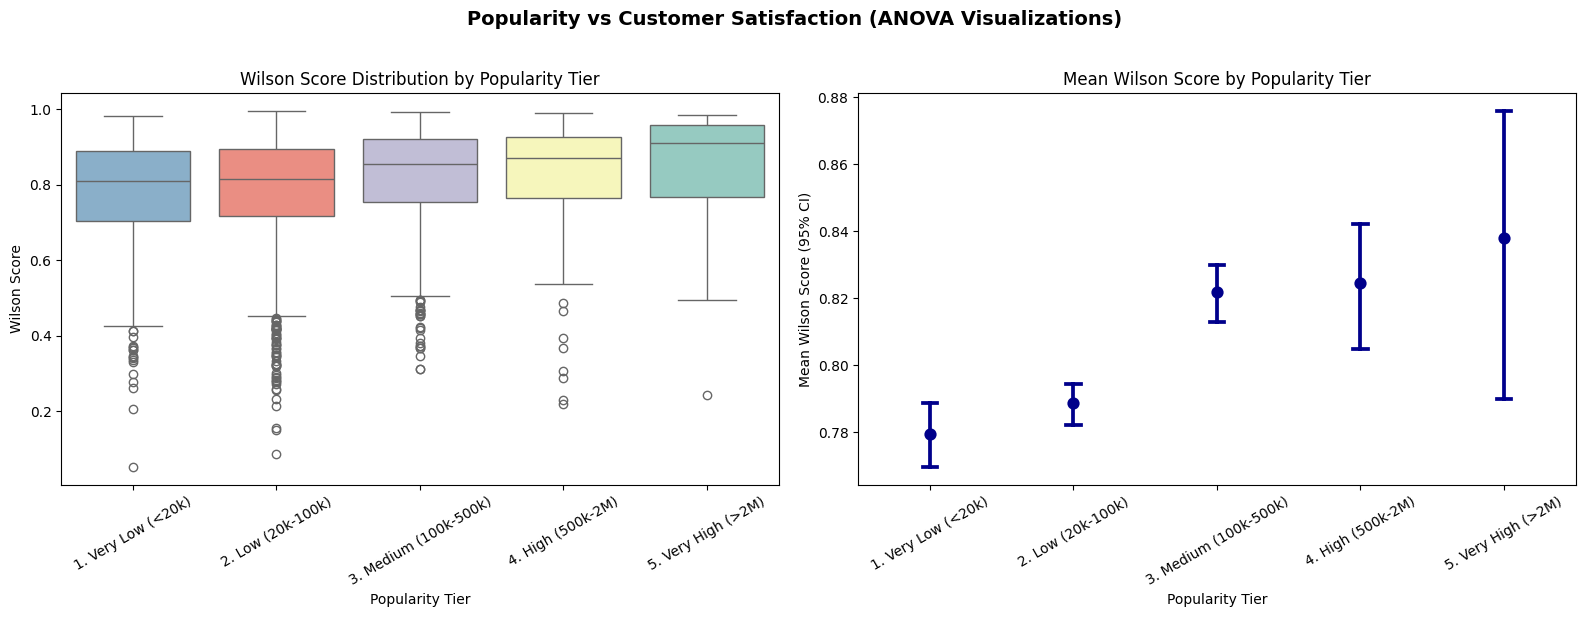

In [6]:
# Owners vs Wilson Score
# Use log scale for owners (highly skewed distribution)
df_plot = df[df['owners_min_known'] == True].copy()

# Pearson correlation (log scale)
r_pearson, p_pearson = scipy_stats.pearsonr(np.log10(df_plot['owners_midpoint']), df_plot['wilson_score'])
# Spearman rank correlation
r_spearman, p_spearman = scipy_stats.spearmanr(df_plot['owners_midpoint'], df_plot['wilson_score'])

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    np.log10(df_plot['owners_midpoint']), df_plot['wilson_score'],
    c=df_plot['wilson_score'], cmap='viridis', alpha=0.5, s=20
)

# Fit linear regression for trendline on log scale
m, b = np.polyfit(np.log10(df_plot['owners_midpoint']), df_plot['wilson_score'], 1)
ax.plot(np.log10(df_plot['owners_midpoint']), m * np.log10(df_plot['owners_midpoint']) + b, color='red', linestyle='--', linewidth=2, label=f'Trendline (r = {r_pearson:.4f})')

ax.set_xlabel('log10(Owners Midpoint)')
ax.set_ylabel('Wilson Score')
ax.set_title('Owners vs Wilson Score (Log Scale)')
plt.colorbar(scatter, ax=ax, label='Wilson Score')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Pearson correlation (log10(owners) vs wilson_score): r = {r_pearson:.4f}, p = {p_pearson:.2e}')
print(f'Spearman rank correlation (owners vs wilson_score): rho = {r_spearman:.4f}, p = {p_spearman:.2e}')

# Group Comparison (One-way ANOVA) on Popularity Tiers
def get_popularity_tier(row):
    if row['owners_min_known'] == False or pd.isna(row['owners_midpoint']):
        return '1. Very Low (<20k)'
    mid = row['owners_midpoint']
    if mid <= 75000:
        return '2. Low (20k-100k)'
    elif mid <= 350000:
        return '3. Medium (100k-500k)'
    elif mid <= 1500000:
        return '4. High (500k-2M)'
    else:
        return '5. Very High (>2M)'

df['popularity_tier'] = df.apply(get_popularity_tier, axis=1)

# Run ANOVA
groups_pop = [group['wilson_score'].values for _, group in df.groupby('popularity_tier')]
f_stat_pop, p_val_pop = scipy_stats.f_oneway(*groups_pop)

print('\n=== One-way ANOVA: Popularity Tiers ===')
print(f'F-statistic = {f_stat_pop:.3f}')
print(f'p-value = {p_val_pop:.2e}')

# Visualize ANOVA
popularity_order = ['1. Very Low (<20k)', '2. Low (20k-100k)', '3. Medium (100k-500k)', '4. High (500k-2M)', '5. Very High (>2M)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(
    x='popularity_tier',
    y='wilson_score',
    data=df,
    order=popularity_order,
    ax=axes[0],
    palette='Set3',
    hue='popularity_tier',
    legend=False
)
axes[0].set_xlabel('Popularity Tier')
axes[0].set_ylabel('Wilson Score')
axes[0].set_title('Wilson Score Distribution by Popularity Tier')
axes[0].tick_params(axis='x', rotation=30)

# Point plot of mean with 95% CI
sns.pointplot(
    x='popularity_tier',
    y='wilson_score',
    data=df,
    order=popularity_order,
    ax=axes[1],
    color='darkblue',
    join=False,
    errorbar=('ci', 95),
    capsize=0.1
)
axes[1].set_xlabel('Popularity Tier')
axes[1].set_ylabel('Mean Wilson Score (95% CI)')
axes[1].set_title('Mean Wilson Score by Popularity Tier')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("Popularity vs Customer Satisfaction (ANOVA Visualizations)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 4. Developer Rankings

In [7]:
# Top developers (>= 3 games)
dev_stats = []
for dev, sub in df.groupby('developer'):
    if len(sub) >= 3:
        tr = sub['total_ratings']
        wr = (sub['rating_ratio'] * tr).sum() / tr.sum()
        ws = (sub['wilson_score'] * tr).sum() / tr.sum()
        dev_stats.append({
            'Developer': dev, 'Games': len(sub),
            'Weighted Rating': wr, 'Weighted Wilson': ws,
            'Avg Price': sub['price'].mean(),
        })

dev_df = pd.DataFrame(dev_stats).sort_values('Weighted Wilson', ascending=False)
print('Top 20 Developers:')
print(dev_df.head(20).to_string(index=False))

Top 20 Developers:
              Developer  Games  Weighted Rating  Weighted Wilson  Avg Price
       Flipline Studios      3         0.991071         0.988182   5.990000
                Devcats      6         0.991235         0.986533   3.490000
               EverCats      3         0.984375         0.969588   4.990000
        Randumb Studios      3         0.979790         0.962326   3.990000
                  Navel      3         0.970756         0.962152  36.656667
         Travellin Cats      5         0.971939         0.960030   1.790000
         Follow the fun      3         0.967010         0.958619   1.326667
        Nukearts Studio      4         0.972696         0.951070   3.240000
Very Very LITTLE Studio      3         0.964714         0.944705   1.990000
         John Szymanski      3         0.954405         0.942169  14.990000
     Steppe Hare Studio      3         0.953862         0.939330   7.323333
                  ATLUS      9         0.938503         0.935780  52.

## 5. Statistical Tests

=== Welch's T-test: Free vs Paid ===
Free:   n=256, mean=0.7265, std=0.1807
Paid:   n=3,612, mean=0.8018, std=0.1358
t-statistic = 6.543
p-value = 2.92e-10
Cohen's d = 0.541 (MEDIUM effect)
Conclusion: Significant difference


C:\Users\Tuyen\AppData\Local\Temp\ipykernel_24800\3673774035.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Paid (0)', 'Free (1)'])


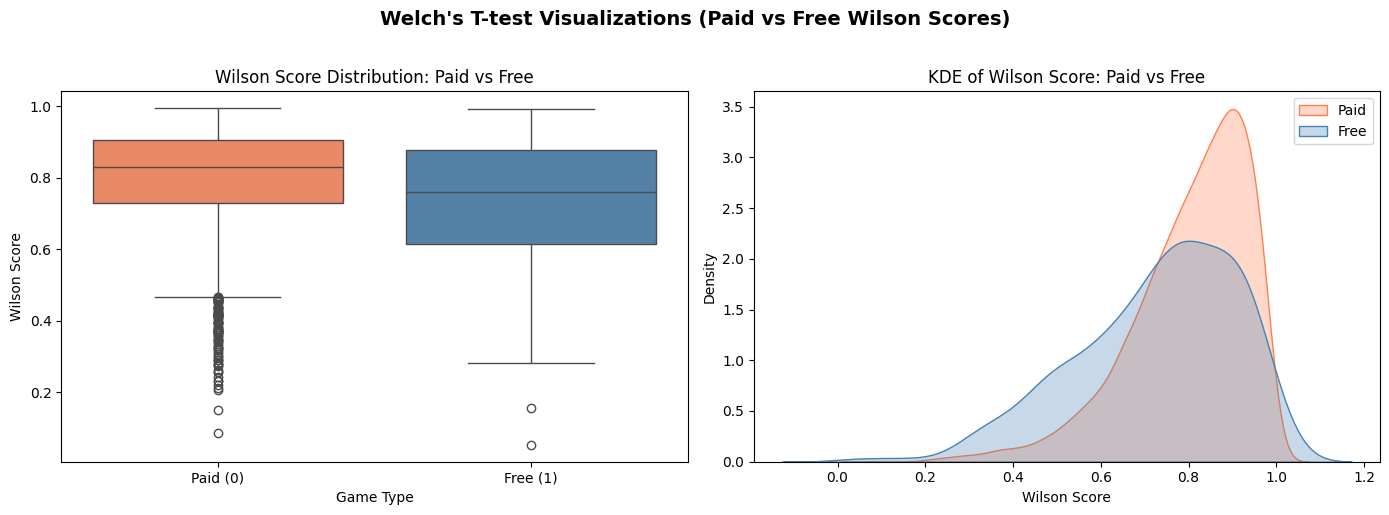

In [8]:
# 5.1 Welch's T-test: Free vs Paid games

free = df[df['is_free'] == 1]['wilson_score']
paid = df[df['is_free'] == 0]['wilson_score']

t_stat, p_val = scipy_stats.ttest_ind(paid, free, equal_var=False)
mean_free, mean_paid = free.mean(), paid.mean()
std_free, std_paid = free.std(), paid.std()
pooled_std = np.sqrt(((len(free)-1)*std_free**2 + (len(paid)-1)*std_paid**2) / (len(free)+len(paid)-2))
cohens_d = (mean_paid - mean_free) / pooled_std

print("=== Welch's T-test: Free vs Paid ===")
print(f'Free:   n={len(free):,}, mean={mean_free:.4f}, std={std_free:.4f}')
print(f'Paid:   n={len(paid):,}, mean={mean_paid:.4f}, std={std_paid:.4f}')
print(f't-statistic = {t_stat:.3f}')
print(f'p-value = {p_val:.2e}')
print(f"Cohen's d = {cohens_d:.3f} ({'SMALL' if abs(cohens_d) < 0.5 else 'MEDIUM' if abs(cohens_d) < 0.8 else 'LARGE'} effect)")
print(f'Conclusion: {"Significant difference" if p_val < 0.05 else "No significant difference"}')

# Visualization for Welch's T-test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot of Wilson Score for Free vs Paid games
sns.boxplot(
    x='is_free',
    y='wilson_score',
    data=df,
    ax=axes[0],
    palette=['coral', 'steelblue'],
    hue='is_free',
    legend=False
)
axes[0].set_xticklabels(['Paid (0)', 'Free (1)'])
axes[0].set_xlabel('Game Type')
axes[0].set_ylabel('Wilson Score')
axes[0].set_title('Wilson Score Distribution: Paid vs Free')

# KDE Plot
sns.kdeplot(paid, ax=axes[1], color='coral', label='Paid', fill=True, alpha=0.3)
sns.kdeplot(free, ax=axes[1], color='steelblue', label='Free', fill=True, alpha=0.3)
axes[1].set_xlabel('Wilson Score')
axes[1].set_ylabel('Density')
axes[1].set_title('KDE of Wilson Score: Paid vs Free')
axes[1].legend()

plt.suptitle("Welch's T-test Visualizations (Paid vs Free Wilson Scores)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


=== One-way ANOVA: Price Groups ===
F-statistic = 34.175
p-value = 8.57e-22
eta^2 = 0.0258 (2.6% variance explained)
Conclusion: Significant difference across price groups


C:\Users\Tuyen\AppData\Local\Temp\ipykernel_24800\409889240.py:39: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


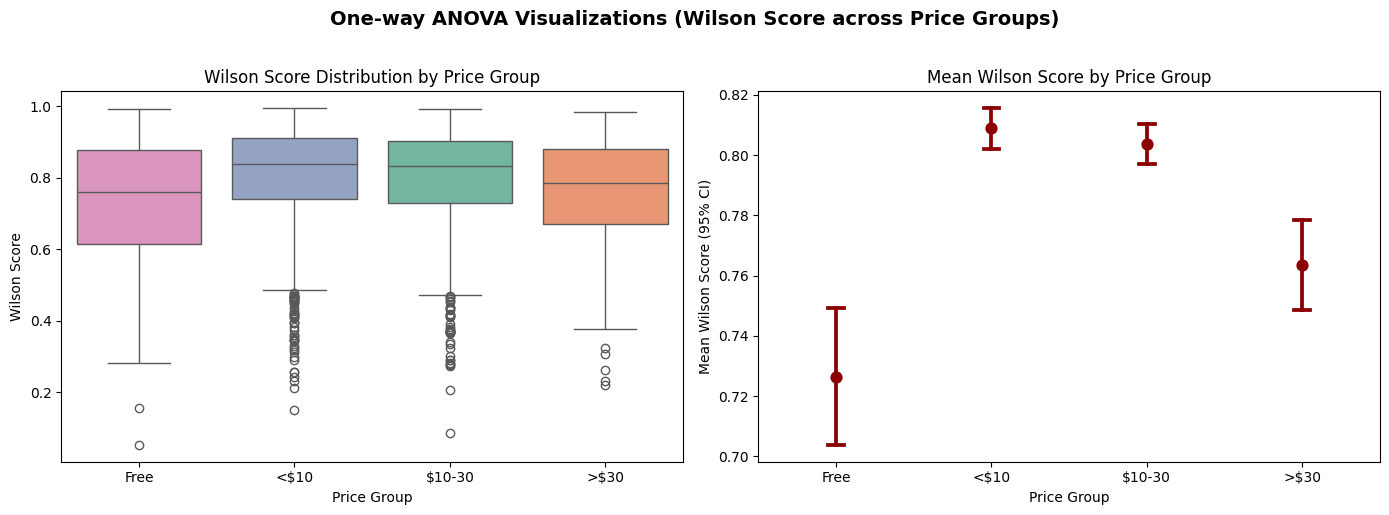

In [9]:
# 5.2 One-way ANOVA: Rating across price groups (all games)

groups = [group['wilson_score'].values for _, group in df.groupby('price_group')]

f_stat, p_val_anova = scipy_stats.f_oneway(*groups)

grand_mean = df['wilson_score'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in [pd.Series(g) for g in groups])
ss_total = ((df['wilson_score'] - grand_mean)**2).sum()
eta_sq = ss_between / ss_total

print('=== One-way ANOVA: Price Groups ===')
print(f'F-statistic = {f_stat:.3f}')
print(f'p-value = {p_val_anova:.2e}')
print(f'eta^2 = {eta_sq:.4f} ({eta_sq*100:.1f}% variance explained)')
print(f'Conclusion: {"Significant difference" if p_val_anova < 0.05 else "No significant difference"} across price groups')

# Visualization for One-way ANOVA
price_group_order = ['Free', '<$10', '$10-30', '>$30']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot of Wilson Score across price groups
sns.boxplot(
    x='price_group',
    y='wilson_score',
    data=df,
    order=price_group_order,
    ax=axes[0],
    palette='Set2',
    hue='price_group',
    legend=False
)
axes[0].set_xlabel('Price Group')
axes[0].set_ylabel('Wilson Score')
axes[0].set_title('Wilson Score Distribution by Price Group')

# Point plot of mean Wilson Score with 95% CI
sns.pointplot(
    x='price_group',
    y='wilson_score',
    data=df,
    order=price_group_order,
    ax=axes[1],
    color='darkred',
    join=False,
    errorbar=('ci', 95),
    capsize=0.1
)
axes[1].set_xlabel('Price Group')
axes[1].set_ylabel('Mean Wilson Score (95% CI)')
axes[1].set_title('Mean Wilson Score by Price Group')

plt.suptitle("One-way ANOVA Visualizations (Wilson Score across Price Groups)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


=== Normality Check (Shapiro-Wilk) ===
    Variable Skewness Kurtosis Shapiro p Normal?
rating_ratio    -1.37    +2.40   < 0.001      NO
       price    +1.67    +3.34   < 0.001      NO
wilson_score    -1.19    +1.66   < 0.001      NO

Note: Non-normal variables are acceptable for large samples (n > 30) via CLT.


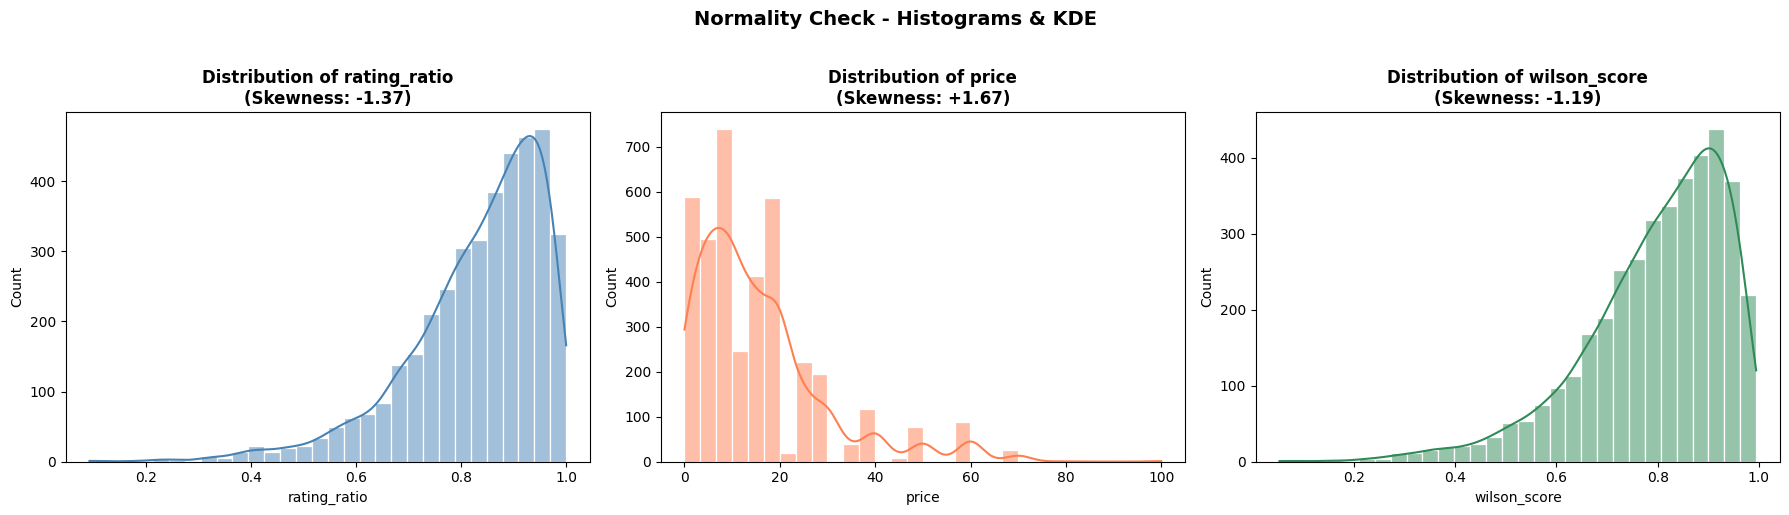

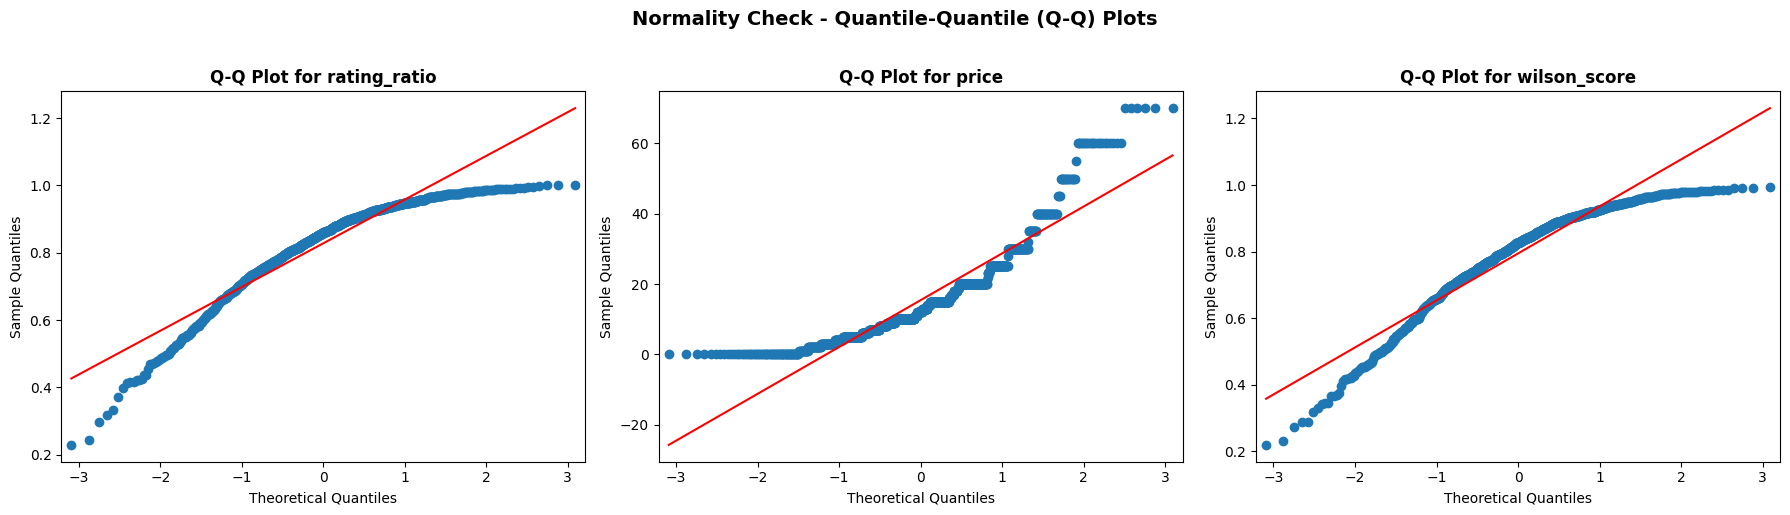

In [10]:
# 5.3 Normality Check (Shapiro-Wilk)

print('=== Normality Check (Shapiro-Wilk) ===')
variables = ['rating_ratio', 'price', 'wilson_score']
norm_data = []
for var in variables:
    data = df[var].dropna()
    sample = data.sample(min(len(data), 3000), random_state=42)
    shapiro_stat, shapiro_p = scipy_stats.shapiro(sample)
    norm_data.append({
        'Variable': var,
        'Skewness': f'{data.skew():+.2f}',
        'Kurtosis': f'{data.kurtosis():+.2f}',
        'Shapiro p': f'{shapiro_p:.2e}' if shapiro_p >= 0.001 else '< 0.001',
        'Normal?': 'YES' if shapiro_p >= 0.05 else 'NO',
    })

norm_df = pd.DataFrame(norm_data)
print(norm_df.to_string(index=False))
print('\nNote: Non-normal variables are acceptable for large samples (n > 30) via CLT.')

# Visualization for Normality Check
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['steelblue', 'coral', 'seagreen']

for idx, var in enumerate(variables):
    sns.histplot(df[var].dropna(), bins=30, kde=True, ax=axes[idx], color=colors[idx], edgecolor='white')
    axes[idx].set_title(f'Distribution of {var}\n(Skewness: {df[var].skew():+.2f})', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Count')
    
plt.suptitle("Normality Check - Histograms & KDE", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Q-Q Plots
import statsmodels.api as sm
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, var in enumerate(variables):
    data = df[var].dropna()
    sample = data.sample(min(len(data), 1000), random_state=42)
    sm.qqplot(sample, line='s', ax=axes[idx])
    axes[idx].set_title(f'Q-Q Plot for {var}', fontsize=12, fontweight='bold')
    
plt.suptitle("Normality Check - Quantile-Quantile (Q-Q) Plots", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


=== VIF for Genre Columns ===
                Genre      VIF
Design & Illustration 6.139311
 Animation & Modeling 5.193418
                Indie 2.463019
     Game Development 2.032699
            Adventure 1.791859
               Action 1.561919
     Audio Production 1.520757
               Casual 1.499483
           Simulation 1.496765
                  RPG 1.463011
       Web Publishing 1.411239
             Strategy 1.399053
        Photo Editing 1.386714
            Education 1.380064
               Sports 1.226428
               Racing 1.194859
         Early Access 1.163111
            Utilities 1.148318
         Free To Play 1.105903
Massively Multiplayer 1.103183
           Accounting 1.002322
     Video Production 1.000000

                Genre      VIF
Design & Illustration 6.139311
 Animation & Modeling 5.193418


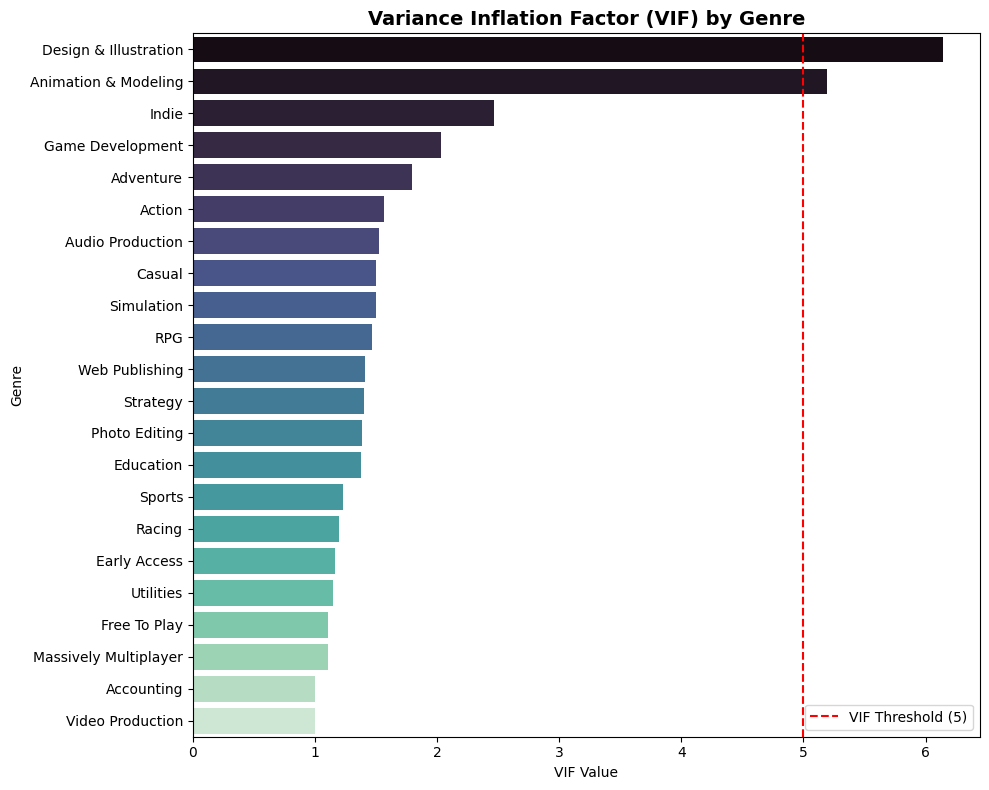

In [11]:
# 5.4 Multicollinearity Check (VIF)

from statsmodels.stats.outliers_influence import variance_inflation_factor

genre_cols = [c for c in df.columns if c.startswith('genre_')]
X = df[genre_cols].astype(float)

vif_data = []
for i, col in enumerate(genre_cols):
    vif = variance_inflation_factor(X.values, i)
    vif_data.append({'Genre': col.replace('genre_', ''), 'VIF': vif})

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)
print('=== VIF for Genre Columns ===')
print(vif_df.to_string(index=False))

high_vif = vif_df[vif_df['VIF'] > 5]
if len(high_vif) == 0:
    print('\nConclusion: All VIF < 5 — no multicollinearity among genre columns.')
else:
    print(f'\nWarning: {len(high_vif)} genres with VIF > 5')
    print(high_vif.to_string(index=False))

# Visualization for VIF
plt.figure(figsize=(10, 8))
sns.barplot(
    x='VIF',
    y='Genre',
    data=vif_df,
    palette='mako',
    hue='Genre',
    legend=False
)
plt.axvline(x=5, color='red', linestyle='--', label='VIF Threshold (5)')
plt.title('Variance Inflation Factor (VIF) by Genre', fontsize=14, fontweight='bold')
plt.xlabel('VIF Value')
plt.ylabel('Genre')
plt.legend()
plt.tight_layout()
plt.show()
